Выполнил: Юрченко Анна Никитична М8о-310Б-23

In [239]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectPercentile, f_regression
import warnings

NUMERICAL_STABILITY_EPS = 1e-10
FEATURE_PERCENTILE_TO_KEEP = 30
TARGET_COLUMN_NAME = "RiskScore"
IDENTIFIER_COLUMN_NAME = "ID"

In [240]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Размер обучающей выборки:", train_df.shape)
print("Размер тестовой выборки:", test_df.shape)

Размер обучающей выборки: (11017, 35)
Размер тестовой выборки: (5000, 35)


In [241]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nПризнаки с пропусками:")
print(missing)


Признаки с пропусками:
MonthlyDebtPayments           1031
LoanAmount                    1031
CreditScore                   1031
BaseInterestRate              1031
NetWorth                      1031
TotalAssets                   1031
BankruptcyHistory             1031
LoanPurpose                   1031
CheckingAccountBalance        1031
ApplicationDate                530
Age                            530
AnnualIncome                   530
HomeOwnershipStatus            530
NumberOfCreditInquiries        530
NumberOfOpenCreditLines        530
CreditCardUtilizationRate      530
NumberOfDependents             530
MaritalStatus                  530
LoanDuration                   530
LengthOfCreditHistory          530
PaymentHistory                 530
PreviousLoanDefaults           530
DebtToIncomeRatio              530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
SavingsAccountBalance          530
TotalLiabilities               530
EmploymentStatus               

In [242]:
def clean_target_variable(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    df = df.dropna(subset=[TARGET_COLUMN_NAME])
    df = df[df[TARGET_COLUMN_NAME].abs() <= 200].reset_index(drop=True)
    df[TARGET_COLUMN_NAME] = df[TARGET_COLUMN_NAME].clip(0.0, 100.0)

    print("Очистка целевой переменной завершена:")
    print(f"  Осталось строк: {len(df)}")
    print(f"  Минимум: {df[TARGET_COLUMN_NAME].min():.2f}")
    print(f"  Максимум: {df[TARGET_COLUMN_NAME].max():.2f}")
    print(f"  Среднее: {df[TARGET_COLUMN_NAME].mean():.2f}\n")

    return df
train_df = clean_target_variable(train_df)

Очистка целевой переменной завершена:
  Осталось строк: 10272
  Минимум: 14.84
  Максимум: 97.60
  Среднее: 48.36



In [243]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
print("\nСтатистика числовых признаков (первые 10):")
print(train_df[numeric_cols].describe().T.head(10))


Статистика числовых признаков (первые 10):
                             count           mean            std  \
Age                        10272.0      39.862344      11.604454   
AnnualIncome               10272.0  131532.945483  115827.564691   
CreditScore                 9787.0     677.911515     175.374136   
LoanAmount                  9787.0   29925.122509   27812.837524   
LoanDuration               10272.0      53.425234      24.521956   
NumberOfDependents         10272.0       1.567854       1.417676   
MonthlyDebtPayments         9787.0     546.437928     502.599753   
CreditCardUtilizationRate  10272.0       0.284565       0.159417   
NumberOfOpenCreditLines    10272.0       3.029108       1.738651   
NumberOfCreditInquiries    10272.0       0.977998       0.988643   

                                    min           25%           50%  \
Age                           18.000000     32.000000     40.000000   
AnnualIncome               15000.000000  20891.000000  88994.5000

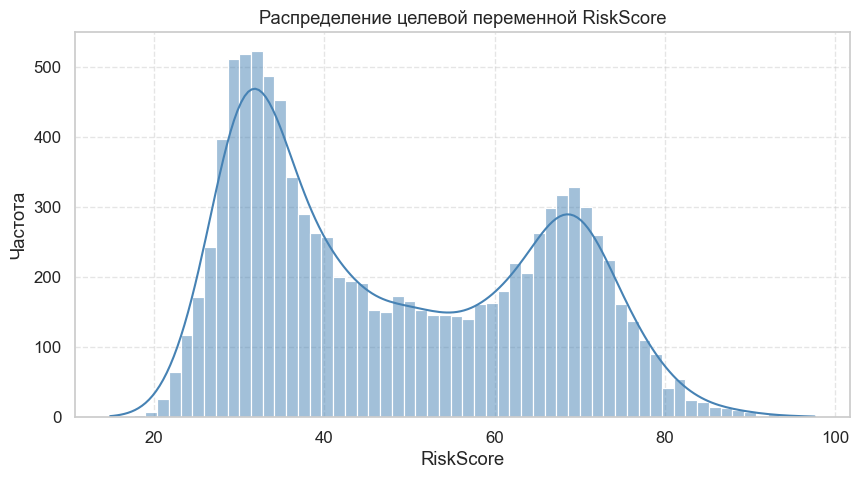

In [244]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df['RiskScore'], bins=60, kde=True, color='steelblue')
plt.title('Распределение целевой переменной RiskScore')
plt.xlabel('RiskScore')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [245]:
q01 = train_df['RiskScore'].quantile(0.01)
q99 = train_df['RiskScore'].quantile(0.99)
cleaned_risk = train_df[(train_df['RiskScore'] >= q01) & (train_df['RiskScore'] <= q99)]['RiskScore']

print(f"\nRiskScore после фильтрации 1–99 перцентилей:")
print(f"Среднее: {cleaned_risk.mean():.2f}")
print(f"Медиана: {cleaned_risk.median():.2f}")
print(f"Стандартное отклонение: {cleaned_risk.std():.2f}")
print(f"Диапазон: [{cleaned_risk.min():.2f}, {cleaned_risk.max():.2f}]")


RiskScore после фильтрации 1–99 перцентилей:
Среднее: 48.24
Медиана: 44.20
Стандартное отклонение: 16.77
Диапазон: [23.16, 82.34]


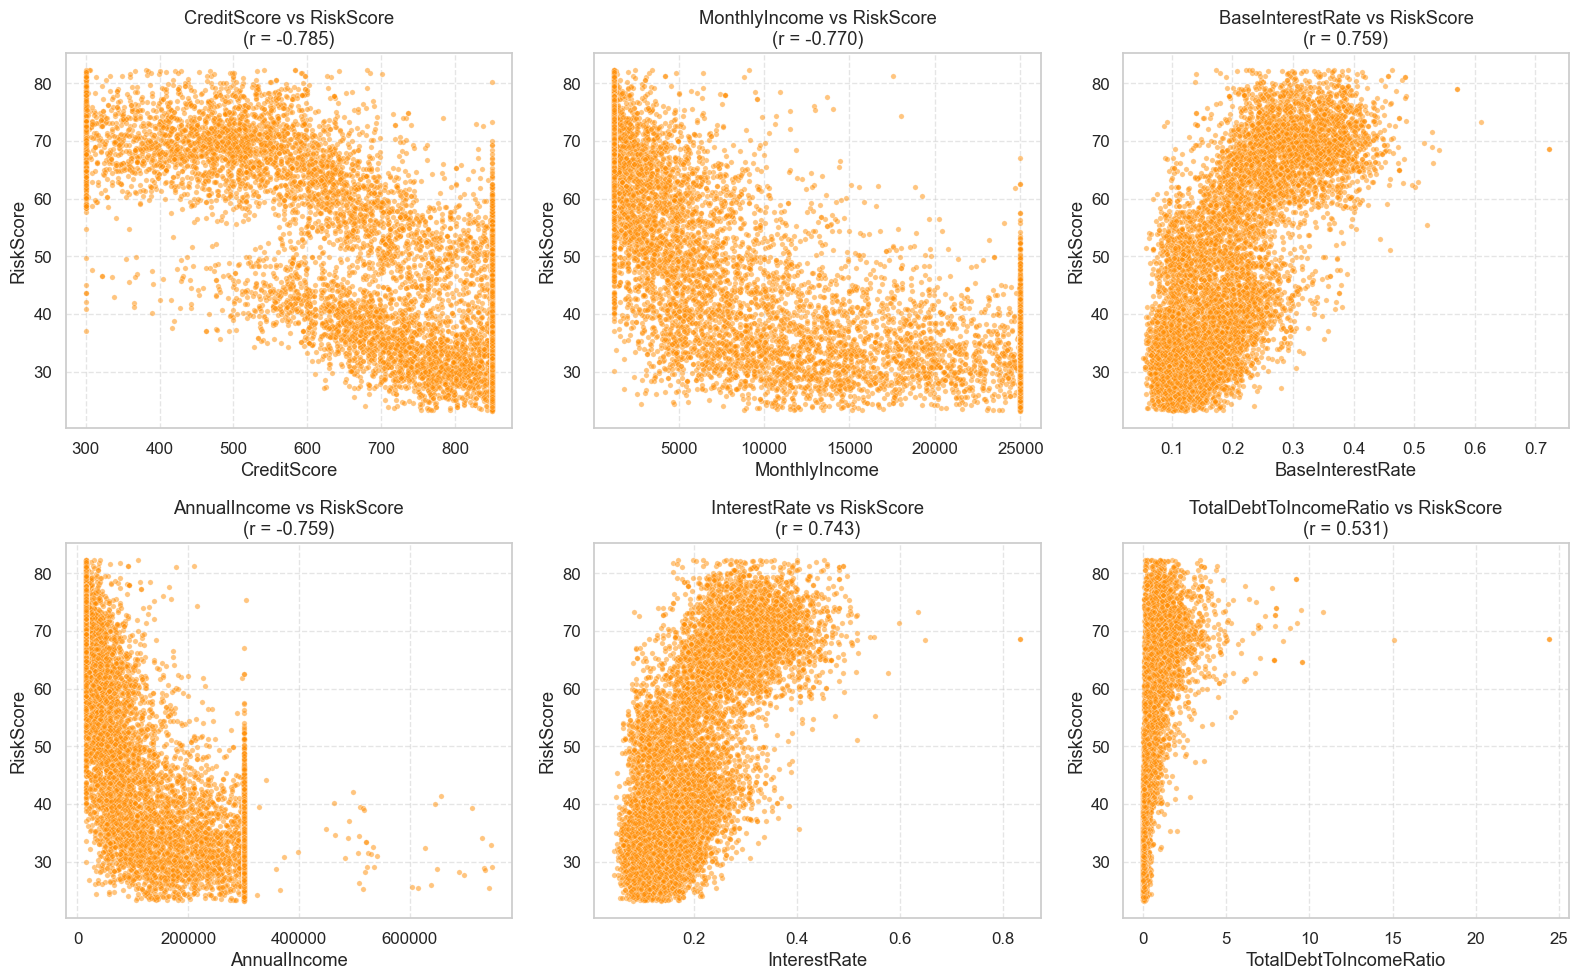

In [246]:
corr_with_target = train_df[numeric_cols].corr()['RiskScore'].abs().sort_values(ascending=False)
top_features = corr_with_target.index[1:7]  # исключаем сам RiskScore

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.scatterplot(
        data=train_df[(train_df['RiskScore'] >= q01) & (train_df['RiskScore'] <= q99)],
        x=col,
        y='RiskScore',
        alpha=0.5,
        s=15,
        ax=axes[i],
        color='darkorange'
    )
    axes[i].set_title(f'{col} vs RiskScore\n(r = {train_df[col].corr(train_df["RiskScore"]):.3f})')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


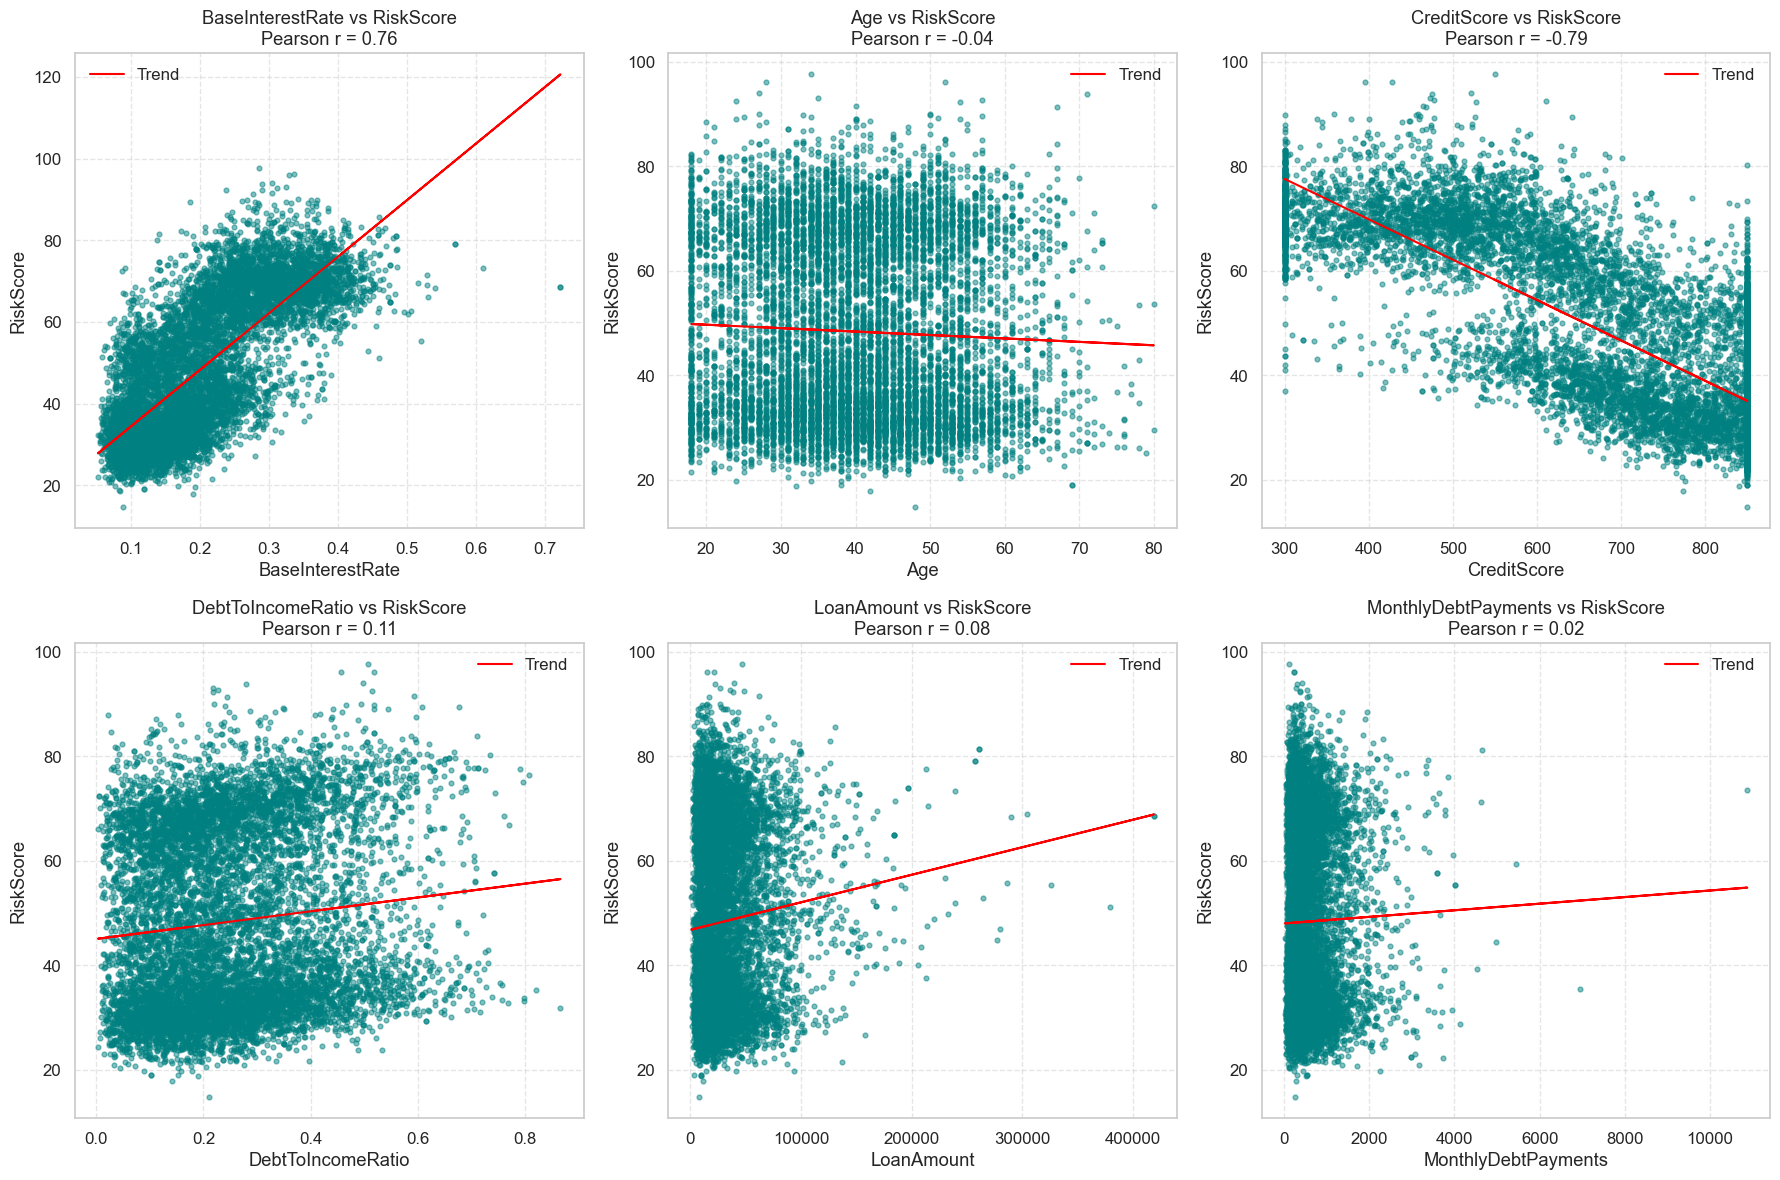

In [273]:
meaningful_features = [
    'BaseInterestRate',
    'Age',
    'CreditScore',
    'DebtToIncomeRatio',
    'LoanAmount',
    'MonthlyDebtPayments'
]

viz_df = train_df[
    (train_df['RiskScore'] >= 0) & (train_df['RiskScore'] <= 100) &
    (train_df['AnnualIncome'] < 1_000_000) &
    (train_df['LoanAmount'] < 500_000)
].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(meaningful_features):
    if feature not in viz_df.columns:
        continue
    ax = axes[i]
    subset = viz_df[[feature, 'RiskScore']].dropna()
    if len(subset) < 10:
        ax.text(0.5, 0.5, 'Недостаточно данных', ha='center', va='center')
        ax.set_title(f'{feature} vs RiskScore')
        continue

    ax.scatter(subset[feature], subset['RiskScore'], alpha=0.5, s=12, color='teal')
    
    m, b = np.polyfit(subset[feature], subset['RiskScore'], 1)
    ax.plot(subset[feature], m * subset[feature] + b, color='red', linewidth=1.5, label='Trend')
    
    corr = subset[feature].corr(subset['RiskScore'])
    ax.set_title(f'{feature} vs RiskScore\nPearson r = {corr:.2f}')
    ax.set_xlabel(feature)
    ax.set_ylabel('RiskScore')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

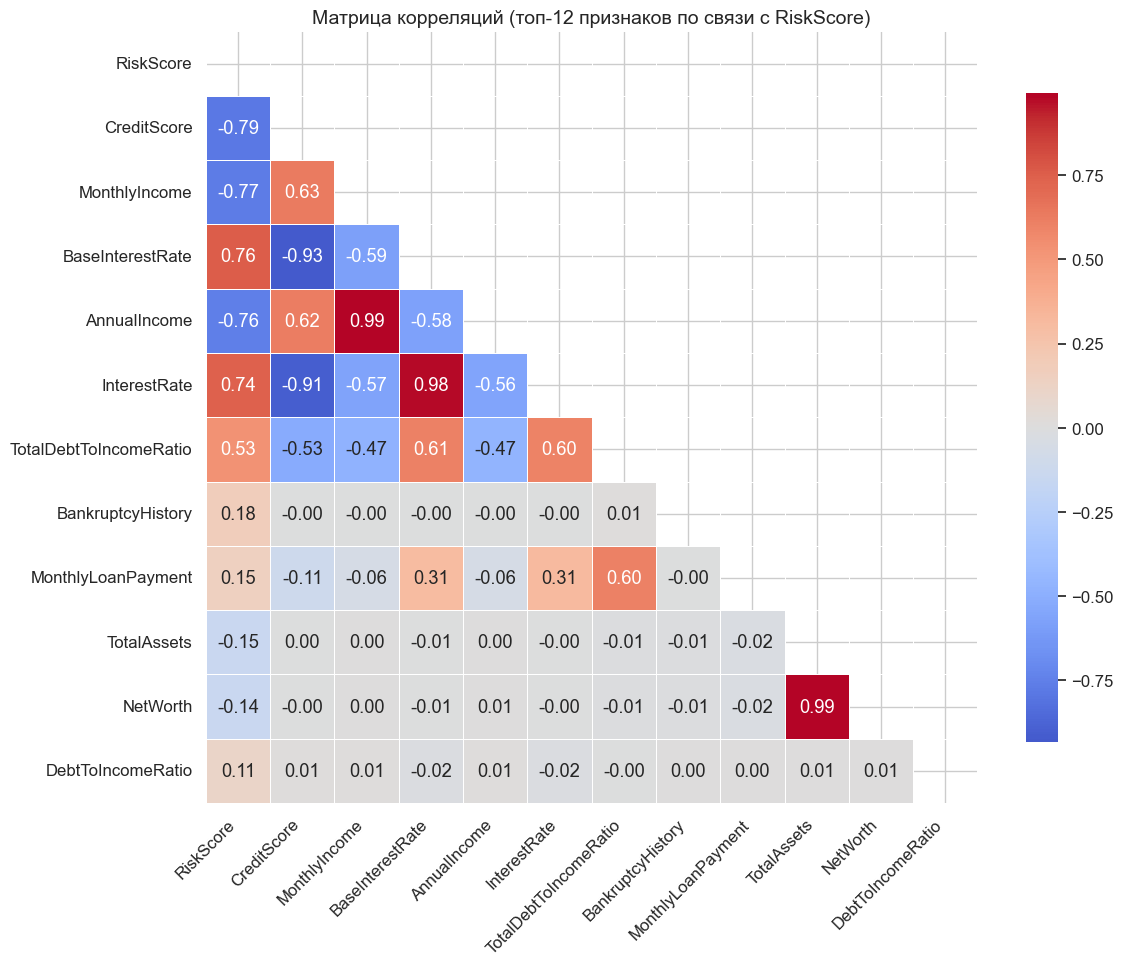

In [247]:

top_corr_cols = corr_with_target.index[:12]
corr_matrix = train_df[top_corr_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Матрица корреляций (топ-12 признаков по связи с RiskScore)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [248]:
def transform_with_signed_log(data: np.ndarray) -> np.ndarray:
    return np.sign(data) * np.log1p(np.abs(data))

def decompose_date_column(df: pd.DataFrame, col_name: str) -> None:
    if col_name not in df.columns:
        return
    dt_series = pd.to_datetime(df[col_name], errors="coerce")
    df[f"{col_name}_Year"] = dt_series.dt.year
    df[f"{col_name}_Month"] = dt_series.dt.month
    df[f"{col_name}_Day"] = dt_series.dt.day
    df[f"{col_name}_DayOfWeek"] = dt_series.dt.dayofweek
    df[f"{col_name}_Quarter"] = dt_series.dt.quarter
    df.drop(columns=[col_name], inplace=True)

def create_binned_feature(df: pd.DataFrame, col_name: str, bin_edges: list, label_style: str = "num") -> None:
    if col_name not in df.columns:
        return
    labels = []
    for i in range(len(bin_edges) - 1):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if np.isinf(hi):
            labels.append(f"{lo}{'+' if label_style == 'num' else ''}")
        else:
            labels.append(f"{lo}-{hi}")
    df[f"{col_name}_Group"] = pd.cut(
        df[col_name], bins=bin_edges, labels=labels, include_lowest=True
    ).astype(str)

def engineer_enhanced_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if all(col in df.columns for col in ['InterestRate', 'BaseInterestRate']):
        df['InterestRateSpread'] = df['InterestRate'] - df['BaseInterestRate']

    if all(col in df.columns for col in ['LoanAmount', 'AnnualIncome']):
        df['LoanToIncome'] = df['LoanAmount'] / (df['AnnualIncome'] + EPS)

    if all(col in df.columns for col in ['MonthlyLoanPayment', 'MonthlyDebtPayments', 'MonthlyIncome']):
        total_debt = df['MonthlyLoanPayment'] + df['MonthlyDebtPayments']
        df['DebtServiceRatio'] = total_debt / (df['MonthlyIncome'] + EPS)
        df['DisposableIncome'] = df['MonthlyIncome'] - total_debt

    if all(col in df.columns for col in ['TotalAssets', 'TotalLiabilities']):
        df['AssetCoverage'] = df['TotalAssets'] / (df['TotalLiabilities'] + EPS)
        df['LiabilityGap'] = df['TotalLiabilities'] - df['TotalAssets']
        df['SignedLogLiabilityGap'] = signed_log1p(df['LiabilityGap'])
        df.drop(columns=["LiabilityGap"], inplace=True)

    if all(col in df.columns for col in ['NetWorth', 'TotalLiabilities']):
        df['NetWorthToLiabilities'] = df['NetWorth'] / (df['TotalLiabilities'] + EPS)

    if all(col in df.columns for col in ['NetWorth', 'AnnualIncome']):
        df['NetWorthToIncome'] = df['NetWorth'] / (df['AnnualIncome'] + EPS)

    if all(col in df.columns for col in ['CreditCardUtilizationRate', 'NumberOfOpenCreditLines']):
        df['UtilizationPerLine'] = df['CreditCardUtilizationRate'] / (df['NumberOfOpenCreditLines'] + 1)

    if all(col in df.columns for col in ['NumberOfCreditInquiries', 'NumberOfOpenCreditLines']):
        df['InquiryPerLine'] = df['NumberOfCreditInquiries'] / (df['NumberOfOpenCreditLines'] + 1)

    if all(col in df.columns for col in ['AnnualIncome', 'NumberOfDependents']):
        df['IncomePerDependent'] = df['AnnualIncome'] / (df['NumberOfDependents'] + 1)

    if all(col in df.columns for col in ['Experience', 'Age']):
        df['ExperienceToAge'] = df['Experience'] / (df['Age'] + EPS)

    if all(col in df.columns for col in ['LoanDuration']):
        df['LoanDurationYears'] = df['LoanDuration'] / 12.0

    if all(col in df.columns for col in ['LengthOfCreditHistory', 'Age']):
        df['CreditHistoryToAge'] = df['LengthOfCreditHistory'] / (df['Age'] + EPS)

    if all(col in df.columns for col in ['AnnualIncome', 'MonthlyIncome']):
        df['IncomeDiscrepancy'] = df['AnnualIncome'] - (df['MonthlyIncome'] * 12.0)

    if all(col in df.columns for col in ['Age', 'Experience']):
        df['AgeAfterExperience'] = df['Age'] - df['Experience']

    if 'CreditScore' in df.columns:
        add_bins(df, "CreditScore", [300, 580, 620, 660, 700, 740, 780, 820, 900])

    if 'AnnualIncome' in df.columns:
        add_bins(df, "AnnualIncome", [0, 40000, 60000, 80000, 100000, 150000, 200000, 300000, np.inf])

    if 'TotalDebtToIncomeRatio' in df.columns:
        add_bins(df, "TotalDebtToIncomeRatio", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 1.0, np.inf])

    if 'InterestRate' in df.columns:
        add_bins(df, "InterestRate", [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, np.inf])

    if 'Age' in df.columns:
        add_bins(df, "Age", [18, 30, 45, 60, np.inf])

    if 'LoanAmount' in df.columns:
        add_bins(df, "LoanAmount", [0, 30000, 60000, 100000, np.inf])

    skewed_cols = ['TotalAssets', 'TotalLiabilities', 'NetWorth', 'AnnualIncome',
                   'LoanAmount', 'MonthlyIncome', 'SavingsAccountBalance']

    for col in skewed_cols:
        if col in df.columns:
            df[col] = signed_log1p(df[col])

    return df

def encode_categorical_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "EducationLevel" in df.columns:
        edu_map = {"High School": 1, "Associate": 2, "Bachelor": 3, "Master": 4, "Doctorate": 5}
        df["EducationLevel"] = df["EducationLevel"].map(edu_map).fillna(0).astype(float)

    if "MaritalStatus" in df.columns:
        marital_map = {"Married": 1, "Single": 2, "Divorced": 3, "Widowed": 4}
        df["MaritalStatus"] = df["MaritalStatus"].map(marital_map).fillna(1).astype(float)

    if "EmploymentStatus" in df.columns:
        emp_map = {"Employed": 1, "Self-Employed": 2, "Unemployed": 3, "Retired": 4}
        df["EmploymentStatus"] = df["EmploymentStatus"].map(emp_map).fillna(1).astype(float)

    if "HomeOwnershipStatus" in df.columns:
        home_map = {"Own": 1, "Mortgage": 2, "Rent": 3, "Other": 4}
        df["HomeOwnershipStatus"] = df["HomeOwnershipStatus"].map(home_map).fillna(2).astype(float)

    return df

In [249]:
class CustomScaler:
    def __init__(self, method='zscore'):
        if method not in ('zscore', 'minmax'):
            raise ValueError(f"Поддерживаемые методы: 'zscore', 'minmax', получено: {method}")
        self.method = method
        self.params_ = {}  # единое хранилище параметров

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.method == 'zscore':
            mean = np.mean(X, axis=0)
            std = np.std(X, axis=0)
            std = np.where(std == 0, 1.0, std)
            self.params_ = {'mean': mean, 'std': std}
        elif self.method == 'minmax':
            min_val = np.min(X, axis=0)
            max_val = np.max(X, axis=0)
            rng = np.where(max_val - min_val == 0, 1.0, max_val - min_val)
            self.params_ = {'min': min_val, 'range': rng}
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.method == 'zscore':
            return (X - self.params_['mean']) / self.params_['std']
        elif self.method == 'minmax':
            return (X - self.params_['min']) / self.params_['range']

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        if self.method == 'zscore':
            return X * self.params_['std'] + self.params_['mean']
        elif self.method == 'minmax':
            return X * self.params_['range'] + self.params_['min']

In [266]:
class LinearModel:
    def __init__(self, optimizer='closed_form', lr=0.001, epochs=500, 
                 batch_sz=64, penalty_type=None, penalty_strength=0.1, 
                 p_norm=2.0, seed=42, debug_mode=False):

        valid_optimizers = ['closed_form', 'batch_gd', 'mini_batch_gd']
        valid_penalties = [None, 'l1', 'l2', 'elastic', 'generalized']
        
        if optimizer not in valid_optimizers:
            raise ValueError(f"Некорректный оптимизатор. Выберите из: {valid_optimizers}")
        if penalty_type not in valid_penalties:
            raise ValueError(f"Некорректный тип регуляризации. Выберите из: {valid_penalties}")
        
        self.optimizer = optimizer
        self.lr = lr
        self.epochs = epochs
        self.batch_sz = batch_sz
        self.penalty_type = penalty_type
        self.penalty_strength = penalty_strength
        self.p_norm = p_norm
        self.debug_mode = debug_mode
        
        self.coef_ = None  
        self.intercept_ = 0.0  
        self.training_history = [] 
        
        np.random.seed(seed)
    
    def _prepare_features(self, X):
        X = np.asarray(X, dtype=np.float64)
        ones_column = np.ones((X.shape[0], 1))
        return np.hstack([ones_column, X])
    
    def _compute_penalty(self, weights):
        if self.penalty_type is None:
            return 0
        
        w = weights[1:]
        
        if self.penalty_type == 'l1':
            return self.penalty_strength * np.sum(np.abs(w))
        elif self.penalty_type == 'l2':
            return self.penalty_strength * np.sum(w ** 2)
        elif self.penalty_type == 'elastic':
            l1_part = 0.5 * self.penalty_strength * np.sum(np.abs(w))
            l2_part = 0.5 * self.penalty_strength * np.sum(w ** 2)
            return l1_part + l2_part
        elif self.penalty_type == 'generalized':
            return self.penalty_strength * np.sum(np.abs(w) ** self.p_norm)
    
    def _compute_penalty_gradient(self, weights):
        if self.penalty_type is None:
            return np.zeros_like(weights)
        
        gradient = np.zeros_like(weights)
        w = weights[1:]
        
        if self.penalty_type == 'l1':
            gradient[1:] = self.penalty_strength * np.sign(w)
        elif self.penalty_type == 'l2':
            gradient[1:] = 2 * self.penalty_strength * w
        elif self.penalty_type == 'elastic':
            gradient[1:] = self.penalty_strength * (0.5 * np.sign(w) + w)
        elif self.penalty_type == 'generalized':
            gradient[1:] = (self.penalty_strength * self.p_norm * 
                           np.sign(w) * (np.abs(w) ** (self.p_norm - 1)))
        
        return gradient
    
    def _solve_closed_form(self, X, y):
        X_b = self._prepare_features(X)
        
        if self.penalty_type == 'l2':
            identity = np.eye(X_b.shape[1])
            identity[0, 0] = 0
            theta = np.linalg.pinv(X_b.T @ X_b + self.penalty_strength * identity) @ X_b.T @ y
        else:
            theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
        
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
    
    def _fit_gradient_descent(self, X, y):
        n_samples, n_features = X.shape
        
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0
        
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).flatten()
        
        for epoch in range(self.epochs):
            if self.optimizer == 'batch_gd':
                y_pred = X @ self.coef_ + self.intercept_
                error = y_pred - y
                
                grad_weights = (2 / n_samples) * (X.T @ error)
                grad_bias = (2 / n_samples) * np.sum(error)
                
                reg_grad_weights = self.full_weights = np.concatenate(([self.intercept_], self.coef_))
                reg_grad = self._compute_penalty_gradient(full_weights)(self.coef_)
                grad_weights += reg_grad[1:]
                grad_bias += reg_grad[0]
                
                self.coef_ -= self.lr * grad_weights
                self.intercept_ -= self.lr * grad_bias
                
            elif self.optimizer == 'mini_batch_gd':
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]
                
                for i in range(0, n_samples, self.batch_sz):
                    X_batch = X_shuffled[i:i + self.batch_sz]
                    y_batch = y_shuffled[i:i + self.batch_sz]
                    batch_size = X_batch.shape[0]
                    
                    y_pred = X_batch @ self.coef_ + self.intercept_
                    error = y_pred - y_batch
                    
                    grad_weights = (2 / batch_size) * (X_batch.T @ error)
                    grad_bias = (2 / batch_size) * np.sum(error)
                    
                    full_weights = np.concatenate(([self.intercept_], self.coef_))
                    reg_grad = self._compute_penalty_gradient(full_weights)
                    grad_weights += reg_grad[1:]
                    grad_bias += reg_grad[0]
                    
                    self.coef_ -= self.lr * grad_weights
                    self.intercept_ -= self.lr * grad_bias
            
            if self.debug_mode and epoch % 50 == 0:
                y_pred = X @ self.coef_ + self.intercept_
                mse_loss = np.mean((y_pred - y) ** 2)
                reg_term = self._compute_penalty(np.concatenate(([self.intercept_], self.coef_)))
                total_loss = mse_loss + reg_term
                self.training_history.append((epoch, total_loss))
                if self.debug_mode:
                    print(f"Эпоха {epoch}/{self.epochs}, Loss: {total_loss:.6f}")
    
    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64).flatten()
        
        X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
        y = np.nan_to_num(y, nan=0.0, posinf=1e10, neginf=-1e10)
        
        if self.optimizer == 'closed_form':
            if self.penalty_type in ['l1', 'elastic', 'generalized']:
                print(f"Предупреждение: Аналитическое решение не поддерживает {self.penalty_type} регуляризацию. ")
                print("Автоматически переключаюсь на градиентный спуск.")
                self.optimizer = 'mini_batch_gd'
                self._fit_gradient_descent(X, y)
            else:
                self._solve_closed_form(X, y)
        elif self.optimizer in ['batch_gd', 'mini_batch_gd']:
            self._fit_gradient_descent(X, y)
        else:
            raise ValueError(f"Неизвестный метод оптимизации: {self.optimizer}")
        
        if self.debug_mode:
            print("Обучение модели завершено+")
        
        return self
    
    def predict(self, X):
        if self.coef_ is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод fit().")
        
        X = np.asarray(X, dtype=np.float64)
        X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
        
        return X @ self.coef_ + self.intercept_
    
    def get_params(self):
        return {
            'intercept': self.intercept_,
            'coefficients': self.coef_,
            'optimizer': self.optimizer,
            'penalty_type': self.penalty_type,
            'penalty_strength': self.penalty_strength
        }

In [251]:
class ValidationSplitter:
    def __init__(self, strategy='k_fold', n_folds=5, shuffle_data=True, seed=42):
        valid_strategies = ['k_fold', 'leave_one_out']
        if strategy not in valid_strategies:
            raise ValueError(f"Некорректная стратегия валидации. Допустимые значения: {valid_strategies}")
        
        if n_folds < 2:
            raise ValueError("Количество фолдов должно быть не менее 2")
        
        self.strategy = strategy
        self.n_folds = n_folds
        self.shuffle_data = shuffle_data
        self.seed = seed
        self._rng = np.random.default_rng(seed)
    
    def _generate_indices(self, data_length):
        indices = np.arange(data_length)
        if self.shuffle_data:
            self._rng.shuffle(indices)
        return indices
    
    def get_splits(self, data, target=None):
        if not hasattr(data, '__len__'):
            raise ValueError("Входные данные должны быть итерируемыми")
        
        n_samples = len(data)
        
        if self.strategy == 'leave_one_out' and n_samples < 2:
            raise ValueError("Для LOO кросс-валидации необходимо минимум 2 объекта")
        
        if self.strategy == 'k_fold' and n_samples < self.n_folds:
            raise ValueError(f"Количество объектов ({n_samples}) меньше количества фолдов ({self.n_folds})")
        
        indices = self._generate_indices(n_samples)
        
        if self.strategy == 'k_fold':
            fold_sizes = np.full(self.n_folds, n_samples // self.n_folds, dtype=int)
            fold_sizes[:n_samples % self.n_folds] += 1
            
            current = 0
            for fold_size in fold_sizes:
                start, end = current, current + fold_size
                test_indices = indices[start:end]
                train_indices = np.concatenate([indices[:start], indices[end:]])
                yield train_indices, test_indices
                current = end
                
        elif self.strategy == 'leave_one_out':
            for i in range(n_samples):
                test_indices = np.array([indices[i]])
                train_indices = np.delete(indices, i)
                yield train_indices, test_indices
    
    def get_n_splits(self, data=None):
        if self.strategy == 'k_fold':
            return self.n_folds
        elif self.strategy == 'leave_one_out':
            if data is None:
                raise ValueError("Для LOO необходимо передать данные для определения количества разделений")
            return len(data)
    
    def __repr__(self):
        return (f"ValidationSplitter(strategy='{self.strategy}', "
                f"n_folds={self.n_folds}, "
                f"shuffle_data={self.shuffle_data}, "
                f"seed={self.seed})")

In [252]:
def calculate_mean_squared_error(actual_values, predicted_values):
    actual = np.asarray(actual_values, dtype=np.float64)
    predicted = np.asarray(predicted_values, dtype=np.float64)
    
    squared_errors = np.square(actual - predicted)
    
    return np.mean(squared_errors)


def compute_mean_absolute_error(actual_values, predicted_values):
    actual = np.asarray(actual_values, dtype=np.float64)
    predicted = np.asarray(predicted_values, dtype=np.float64)
    
    absolute_errors = np.abs(actual - predicted)
    
    return np.mean(absolute_errors)


def evaluate_r_squared(actual_values, predicted_values):
    actual = np.asarray(actual_values, dtype=np.float64)
    predicted = np.asarray(predicted_values, dtype=np.float64)
    
    residual_sum_of_squares = np.sum(np.square(actual - predicted))
    
    total_sum_of_squares = np.sum(np.square(actual - np.mean(actual)))
    
    epsilon = 1e-10
    if total_sum_of_squares < epsilon:
        return 0.0
    
    r_squared = 1 - (residual_sum_of_squares / total_sum_of_squares)
    
    return r_squared


def assess_mean_absolute_percentage_error(actual_values, predicted_values):
    actual = np.asarray(actual_values, dtype=np.float64)
    predicted = np.asarray(predicted_values, dtype=np.float64)
    
    valid_indices = np.abs(actual) > 1e-10
    
    if not np.any(valid_indices):
        return 0.0
    
    absolute_percentage_errors = np.abs(
        (actual[valid_indices] - predicted[valid_indices]) / 
        (actual[valid_indices] + 1e-10)  
    )
    
    return np.mean(absolute_percentage_errors) * 100.0

In [253]:
class DataModelingPipeline:
    def __init__(self, model_type='sklearn', learning_rate=0.01, max_epochs=1000, 
                 mini_batch_size=32, show_progress=False, normalization='standard',
                 polynomial_features=True, feature_reduction=True, random_seed=42):
        self.model_type = model_type
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.mini_batch_size = mini_batch_size
        self.show_progress = show_progress
        self.normalization = normalization
        self.polynomial_features = polynomial_features
        self.feature_reduction = feature_reduction
        self.random_seed = random_seed
        
        self.numeric_imputers = {}
        self.categorical_imputers = {}
        self.numeric_scalers = {}
        self.feature_transformer = None
        self.categorical_encoder = None
        self.feature_selector = None
        self.regression_model = None
        self.column_types = {}
        self.feature_names = None
        self.selected_indices = None
        
        np.random.seed(self.random_seed)
    
    def _identify_column_types(self, X):
        numeric_columns = X.select_dtypes(include=[np.number]).columns.tolist()
        categorical_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
        
        self.column_types = {
            'numeric': numeric_columns,
            'categorical': categorical_columns
        }
        
        return numeric_columns, categorical_columns
    
    def _handle_missing_values(self, X, is_training=False):
        X_processed = X.copy()
        
        numeric_cols = self.column_types['numeric']
        for col in numeric_cols:
            if is_training:
                median_value = X_processed[col].median()
                self.numeric_imputers[col] = median_value
            else:
                median_value = self.numeric_imputers.get(col, X_processed[col].median())
            
            X_processed[col].fillna(median_value, inplace=True)
        
        categorical_cols = self.column_types['categorical']
        for col in categorical_cols:
            if is_training:
                mode_value = X_processed[col].mode()
                mode_value = mode_value.iloc[0] if not mode_value.empty else 'Unknown'
                self.categorical_imputers[col] = mode_value
            else:
                mode_value = self.categorical_imputers.get(col, 'Unknown')
            
            X_processed[col].fillna(mode_value, inplace=True)
        
        return X_processed
    
    def _normalize_features(self, X, is_training=False):
        X_processed = X.copy()
        numeric_cols = self.column_types['numeric']
        
        if not numeric_cols:
            return X_processed
        
        if is_training:
            if self.normalization == 'standard':
                self.numeric_scalers['mean'] = X_processed[numeric_cols].mean()
                self.numeric_scalers['std'] = X_processed[numeric_cols].std().replace(0, 1)
            elif self.normalization == 'minmax':
                self.numeric_scalers['min'] = X_processed[numeric_cols].min()
                self.numeric_scalers['max'] = X_processed[numeric_cols].max()
                self.numeric_scalers['range'] = (self.numeric_scalers['max'] - 
                                                self.numeric_scalers['min']).replace(0, 1)
        
        if self.normalization == 'standard':
            X_processed[numeric_cols] = (X_processed[numeric_cols] - self.numeric_scalers['mean']) / self.numeric_scalers['std']
        elif self.normalization == 'minmax':
            X_processed[numeric_cols] = (X_processed[numeric_cols] - self.numeric_scalers['min']) / self.numeric_scalers['range']
        
        return X_processed
    
    def _create_polynomial_features(self, X, is_training=False):
        if not self.polynomial_features or not self.column_types['numeric']:
            return X
        
        numeric_data = X[self.column_types['numeric']].copy()
        
        if is_training:
            self.feature_transformer = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
            poly_features = self.feature_transformer.fit_transform(numeric_data)
            feature_names = self.feature_transformer.get_feature_names_out(self.column_types['numeric'])
            
            poly_df = pd.DataFrame(poly_features, columns=feature_names, index=X.index)
            self.feature_names = feature_names
            
            poly_mean = poly_df.mean()
            poly_std = poly_df.std().replace(0, 1)
            self.feature_transformer.mean_ = poly_mean
            self.feature_transformer.std_ = poly_std
            
            poly_df = (poly_df - poly_mean) / poly_std
            return pd.concat([X.drop(columns=self.column_types['numeric']), poly_df], axis=1)
        else:
            if self.feature_transformer is None:
                return X
            
            poly_features = self.feature_transformer.transform(numeric_data)
            feature_names = self.feature_names
            
            poly_df = pd.DataFrame(poly_features, columns=feature_names, index=X.index)
            poly_df = (poly_df - self.feature_transformer.mean_) / self.feature_transformer.std_
            return pd.concat([X.drop(columns=self.column_types['numeric']), poly_df], axis=1)
    
    def _encode_categorical_features(self, X, is_training=False):
        if not self.column_types['categorical'] or not X.select_dtypes(exclude=[np.number]).shape[1]:
            return X
        
        categorical_data = X[self.column_types['categorical']].copy()
        
        if is_training:
            self.categorical_encoder = OneHotEncoder(
                handle_unknown='ignore', 
                sparse_output=False,
                drop='first'
            )
            encoded_features = self.categorical_encoder.fit_transform(categorical_data)
            feature_names = self.categorical_encoder.get_feature_names_out(self.column_types['categorical'])
            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=X.index)
            return pd.concat([X.drop(columns=self.column_types['categorical']), encoded_df], axis=1)
        else:
            if self.categorical_encoder is None:
                return X
            
            encoded_features = self.categorical_encoder.transform(categorical_data)
            feature_names = self.categorical_encoder.get_feature_names_out(self.column_types['categorical'])
            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=X.index)
            return pd.concat([X.drop(columns=self.column_types['categorical']), encoded_df], axis=1)
    
    def _select_relevant_features(self, X, y=None, is_training=False):
        if not self.feature_reduction:
            return X
        
        if is_training:
            self.feature_selector = SelectPercentile(
                score_func=f_regression, 
                percentile=FEATURE_RETENTION_RATE
            )
            X_selected = self.feature_selector.fit_transform(X, y)
            self.selected_indices = self.feature_selector.get_support(indices=True)
            return X_selected
        else:
            if self.feature_selector is None:
                raise ValueError("Селектор признаков не обучен. Сначала вызовите метод fit().")
            
            if hasattr(X, 'values'):
                X_array = X.values
            else:
                X_array = X
                
            return self.feature_selector.transform(X_array)
    
    def _initialize_regression_model(self):
        if self.model_type == 'simple_sklearn':
            return LinearRegression()
        
        elif self.model_type.startswith('ridge'):
            alpha = float(self.model_type.split('_')[1]) if '_' in self.model_type else self.learning_rate
            return Ridge(alpha=alpha, random_state=self.random_seed)
        
        elif self.model_type.startswith('lasso'):
            alpha = float(self.model_type.split('_')[1]) if '_' in self.model_type else self.learning_rate
            return Lasso(alpha=alpha, random_state=self.random_seed, max_iter=self.max_epochs)
        
        elif self.model_type.startswith('elastic'):
            alpha = float(self.model_type.split('_')[1]) if '_' in self.model_type else self.learning_rate
            l1_ratio = 0.5  # фиксированное соотношение, можно сделать параметром
            return ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=self.random_seed, max_iter=self.max_epochs)
        
        elif self.model_type == 'sgd_sklearn':
            return SGDRegressor(
                loss='squared_error',
                penalty='l2',
                alpha=0.0001,
                max_iter=self.max_epochs,
                learning_rate='constant',
                eta0=self.learning_rate,
                shuffle=True,
                random_state=self.random_seed,
                tol=1e-5,
                early_stopping=True,
                validation_fraction=0.1
            )
        
        else:
            regularization_type = None
            alpha = self.learning_rate
            
            if 'l1' in self.model_type:
                regularization_type = 'l1'
            elif 'l2' in self.model_type:
                regularization_type = 'l2'
            elif 'elastic' in self.model_type:
                regularization_type = 'elasticnet'
            
            optimization_method = 'sgd' if 'sgd' in self.model_type else 'analytical'
            
            return LinearRegressionCustom(
                method=optimization_method,
                learning_rate=self.learning_rate,
                n_iterations=self.max_epochs,
                batch_size=self.mini_batch_size,
                regularization=regularization_type,
                lambda_reg=alpha,
                random_state=self.random_seed,
                verbose=self.show_progress
            )
    
    def fit(self, X_train, y_train):
        numeric_cols, categorical_cols = self._identify_column_types(X_train)
        
        X_processed = X_train.copy()
        X_processed = self._handle_missing_values(X_processed, is_training=True)
        X_processed = self._normalize_features(X_processed, is_training=True)
        X_processed = self._create_polynomial_features(X_processed, is_training=True)
        X_processed = self._encode_categorical_features(X_processed, is_training=True)
        X_selected = self._select_relevant_features(X_processed, y_train, is_training=True)
        self.regression_model = self._initialize_regression_model()
        self.regression_model.fit(X_selected, y_train)
        
        if self.show_progress:
            print("Пайплайн успешно обучен!")
        
        return self
    
    def transform(self, X):
        if self.regression_model is None:
            raise ValueError("Пайплайн не обучен. Сначала вызовите метод fit().")
        
        X_processed = X.copy()
        X_processed = self._handle_missing_values(X_processed, is_training=False)
        X_processed = self._normalize_features(X_processed, is_training=False)
        X_processed = self._create_polynomial_features(X_processed, is_training=False)
        X_processed = self._encode_categorical_features(X_processed, is_training=False)
        
        if self.feature_reduction:
            X_selected = self._select_relevant_features(X_processed, is_training=False)
            return X_selected
        
        return X_processed.values if hasattr(X_processed, 'values') else X_processed
    
    def predict(self, X):
        X_transformed = self.transform(X)
        return self.regression_model.predict(X_transformed)
    
    def evaluate(self, X_val, y_val, metrics=None):
        if metrics is None:
            metrics = ['mse', 'mae', 'r2']
        
        y_pred = self.predict(X_val)
        results = {}
        
        for metric in metrics:
            if metric == 'mse':
                results['mse'] = custom_mse(y_val, y_pred)
            elif metric == 'mae':
                results['mae'] = custom_mae(y_val, y_pred)
            elif metric == 'r2':
                results['r2'] = custom_r2(y_val, y_pred)
            elif metric == 'mape':
                results['mape'] = custom_mape(y_val, y_pred)
        
        return results

In [267]:
def run_full_experiment():
    current_time = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M")

    try:
        training_data = pd.read_csv('train.csv')
        testing_data = pd.read_csv('test.csv')

        if IDENTIFIER_COLUMN_NAME in testing_data.columns:
            submission_ids = testing_data[IDENTIFIER_COLUMN_NAME].copy()
            testing_data = testing_data.drop(IDENTIFIER_COLUMN_NAME, axis=1)
        else:
            submission_ids = pd.Series(range(len(testing_data)), name=IDENTIFIER_COLUMN_NAME)
            print("ID столбец не найден. Созданы искусственные ID.")
    except Exception as data_error:
        print(f"Критическая ошибка при загрузке данных: {data_error}")
        raise

    training_data = clean_target_variable(training_data)
    training_data = engineer_enhanced_features(training_data)
    testing_data = engineer_enhanced_features(testing_data)
    decompose_date_column(training_data, "ApplicationDate")
    decompose_date_column(testing_data, "ApplicationDate")
    training_data = encode_categorical_columns(training_data)
    testing_data = encode_categorical_columns(testing_data)

    features = training_data.drop(columns=[TARGET_COLUMN_NAME])
    target = training_data[TARGET_COLUMN_NAME]
    if IDENTIFIER_COLUMN_NAME in features.columns:
        features = features.drop(columns=[IDENTIFIER_COLUMN_NAME])

    cv = CustomCrossValidator(cv_type='kfold', n_splits=3, shuffle=True, random_state=42)
    regularized_methods = [
        ('ridge_0.1', 'ridge', 0.1),
        ('ridge_1.0', 'ridge', 1.0),
        ('lasso_0.01', 'lasso', 0.01),
        ('lasso_0.1', 'lasso', 0.1),
        ('elastic_0.1', 'elastic', 0.1)
    ]

    mse_results = {}
    for name, method, alpha in regularized_methods:
        mse_scores = []
        print(f"\n    Тестирование модели: {name}")
        for fold_num, (train_idx, val_idx) in enumerate(cv.split(features), 1):
            X_train = features.iloc[train_idx].copy()
            X_val = features.iloc[val_idx].copy()
            y_train = target.iloc[train_idx]
            y_val = target.iloc[val_idx]

            pipe = AdvancedPipeline(
                reg_method=method,
                lr=alpha,
                verbose=False,
                use_poly=True,
                use_feature_selection=True
            )
            try:
                numeric_cols = [col for col in X_train.columns if np.issubdtype(X_train[col].dtype, np.number)]
                cat_cols = [col for col in X_train.columns if col not in numeric_cols]
                pipe.fit(X_train, y_train, numeric_cols, cat_cols)
                pred_val = pipe.predict(X_val)
                mse = custom_mse(y_val.values, pred_val)
                mse_scores.append(mse)
                print(f"      Фолд {fold_num}: MSE = {mse:.4f}")
            except Exception as e:
                print(f"      Ошибка на фолде {fold_num}: {str(e)}")
                mse_scores.append(1000.0)

        mean_mse = np.mean(mse_scores)
        mse_results[name] = mean_mse
        print(f"    Итог для {name}: MSE = {mean_mse:.4f}")

    best_method = min(mse_results, key=mse_results.get)
    best_mse = mse_results[best_method]

    if best_method.startswith(('ridge', 'lasso', 'elastic')):
        method_type, alpha_str = best_method.split('_')
        final_pipe = AdvancedPipeline(
            reg_method=method_type,
            lr=float(alpha_str),
            verbose=True,
            use_poly=True,
            use_feature_selection=True
        )
    else:
        final_pipe = AdvancedPipeline(
            reg_method=best_method,
            verbose=True,
            use_poly=True,
            use_feature_selection=True
        )

    numeric_cols = [col for col in features.columns if np.issubdtype(features[col].dtype, np.number)]
    cat_cols = [col for col in features.columns if col not in numeric_cols]
    final_pipe.fit(features, target, numeric_cols, cat_cols)
    
    y_pred = final_pipe.predict(features)
    print("\n=== ИТОГОВАЯ ОЦЕНКА КАЧЕСТВА МОДЕЛИ ===")
    print(f"• MSE на обучающей выборке (кастомная реализация): {custom_mse(target.values, y_pred):.4f}")
    print(f"• MSE на обучающей выборке (sklearn):                {mean_squared_error(target.values, y_pred):.4f}")
    print(f"• MAE (кастом / sklearn):                           {custom_mae(target.values, y_pred):.4f} / {mean_absolute_error(target.values, y_pred):.4f}")
    print(f"• R² (кастом / sklearn):                            {custom_r2(target.values, y_pred):.4f} / {r2_score(target.values, y_pred):.4f}")
    print(f"• MAPE (кастом / sklearn):                          {custom_mape(target.values, y_pred):.4f}% / {mean_absolute_percentage_error(target.values, y_pred) * 100:.4f}%")

    predictions = np.clip(final_pipe.predict(testing_data), 0.0, 100.0)
    submission = pd.DataFrame({
        IDENTIFIER_COLUMN_NAME: submission_ids,
        TARGET_COLUMN_NAME: predictions
    })
    submission_filename = 'submission.csv'
    submission.to_csv(submission_filename, index=False)
    final_mse = mean_squared_error(target.values, y_pred)
    print(f"Файл сохранён: {submission_filename}")
    print(f"Итоговая MSE на train: {final_mse:.4f}")

    return {
        'pipeline': final_pipe,
        'best_method': best_method,
        'mse_cv': best_mse,
        'mse_train': final_mse,
        'submission_file': submission_filename,
        'predictions': predictions
    }

if __name__ == "__main__":
    try:
        results = run_full_experiment()
    except Exception as e:
        print(f"\nОшибка: {e}")
        import traceback
        traceback.print_exc()

Очистка целевой переменной завершена:
  Осталось строк: 10272
  Минимум: 14.84
  Максимум: 97.60
  Среднее: 48.36


    Тестирование модели: ridge_0.1
      Фолд 1: MSE = 29.1870
      Фолд 2: MSE = 29.3996
      Фолд 3: MSE = 27.9944
    Итог для ridge_0.1: MSE = 28.8603

    Тестирование модели: ridge_1.0
      Фолд 1: MSE = 28.7188
      Фолд 2: MSE = 29.0198
      Фолд 3: MSE = 27.2358
    Итог для ridge_1.0: MSE = 28.3248

    Тестирование модели: lasso_0.01
      Фолд 1: MSE = 27.1788
      Фолд 2: MSE = 25.7693
      Фолд 3: MSE = 25.9300
    Итог для lasso_0.01: MSE = 26.2927

    Тестирование модели: lasso_0.1
      Фолд 1: MSE = 29.3132
      Фолд 2: MSE = 27.7051
      Фолд 3: MSE = 27.7894
    Итог для lasso_0.1: MSE = 28.2692

    Тестирование модели: elastic_0.1
      Фолд 1: MSE = 29.1073
      Фолд 2: MSE = 27.6608
      Фолд 3: MSE = 28.3590
    Итог для elastic_0.1: MSE = 28.3757
Обучение завершено!

=== ИТОГОВАЯ ОЦЕНКА КАЧЕСТВА МОДЕЛИ ===
• MSE на обучающей выборке (